# Реализация деревья решений

## Импорт библиотек

In [31]:
import pandas as pd
import numpy as np
import warnings

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score

In [32]:
warnings.filterwarnings("ignore")

## Загрузка данных

In [33]:
test_df = pd.read_csv('../data/mobile_classification_test.csv')
df = pd.read_csv('../data/mobile_classification_train.csv')

## Описание данных

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [35]:
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


### Целевая переменная

**price_range (0–3):**

0 — низкий сегмент

1 — средний сегмент

2 — высокий сегмент

3 — премиум-сегмент

### Признаки

1. **battery_power**: Емкость аккумулятора (мАч)

2. **blue**: Поддержка Bluetooth (1 — есть, 0 — нет)

3. **clock_speed**: Частота процессора (ГГц)

4. **dual_sim**: Поддержка двух SIM-карт (1 — да, 0 — нет)

5. **fc**: Разрешение фронтальной камеры (МП)

6. **four_g**: Поддержка 4G (1 — да, 0 — нет)

7. **int_memory**: Встроенная память (ГБ)

8. **m_dep**: Толщина устройства (см)

9. **mobile_wt**: Вес телефона (г)

10. **n_cores**: Количество ядер процессора

11. **pc**: Разрешение основной камеры (МП)

12. **px_height**: Высота экрана в пикселях

13. **px_width**: Ширина экрана в пикселях

14. **ram**: Объем оперативной памяти (МБ)

15. **sc_h**: Высота экрана (см)

16. **sc_w**: Ширина экрана (см)

17. **talk_time**: Время разговора (ч)

18. **three_g**: Поддержка 3G (1 — да, 0 — нет)

19. **touch_screen**: Сенсорный экран (1 — да, 0 — нет)

20. **wifi**: Поддержка Wi-Fi (1 — да, 0 — нет)

## Анализ данных

### Проверка дубликатов

In [36]:
df.duplicated().sum()

np.int64(0)

Дубликатов нет

### Общая статистика

In [37]:
df.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


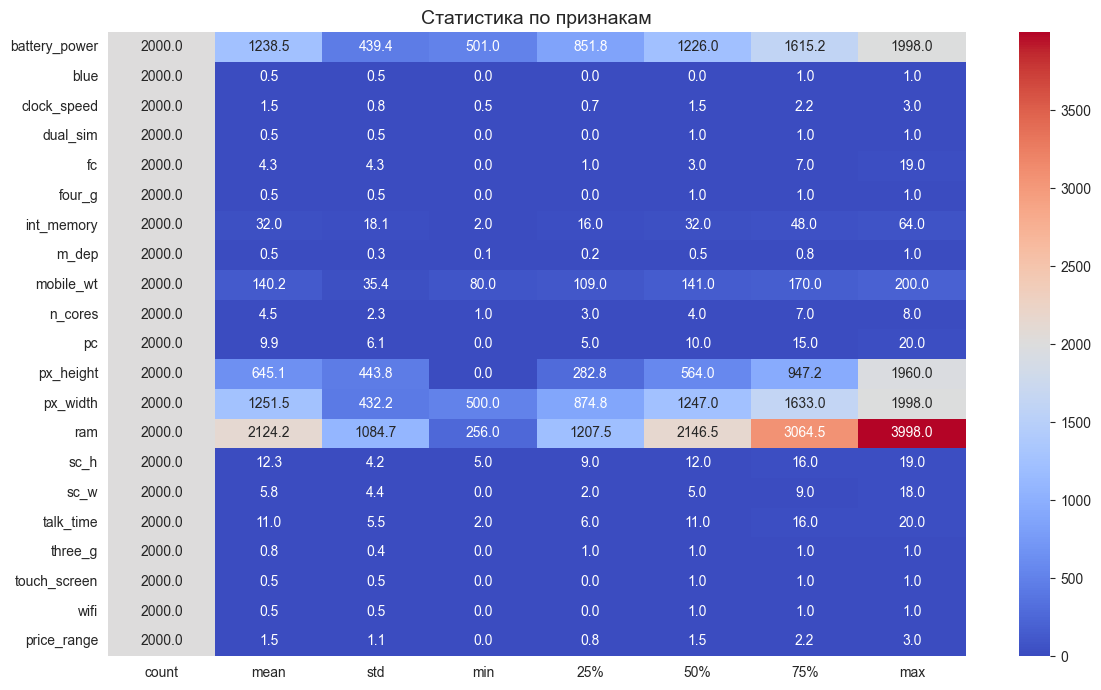

In [38]:
desc = df.describe().transpose()

# Строим тепловую карту
plt.figure(figsize=(12, 7))
sns.heatmap(desc, annot=True, fmt=".1f", cmap="coolwarm")
plt.title("Статистика по признакам", fontsize=14)
plt.tight_layout()
plt.show()

### Boxplot для всех признаков

In [39]:
features = df.drop(columns=['price_range'])

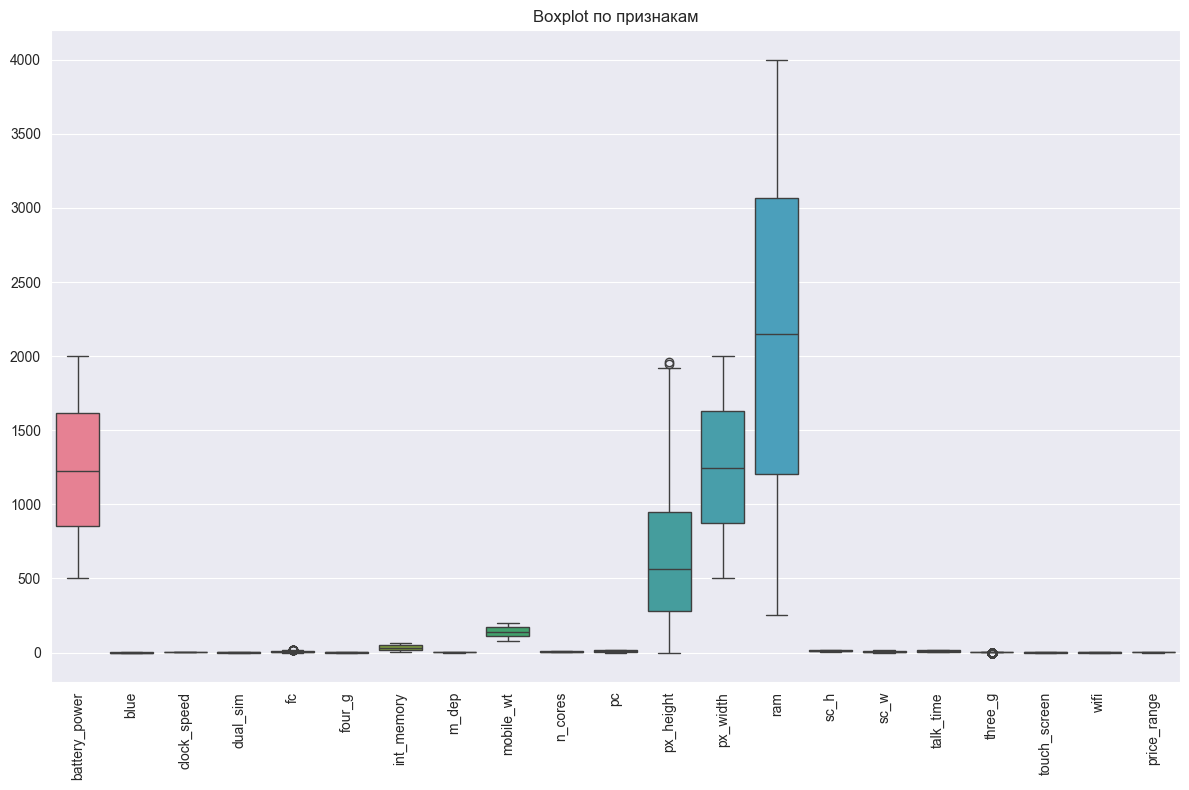

In [40]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Boxplot по признакам")
plt.tight_layout()
plt.show()

### Гистограммы

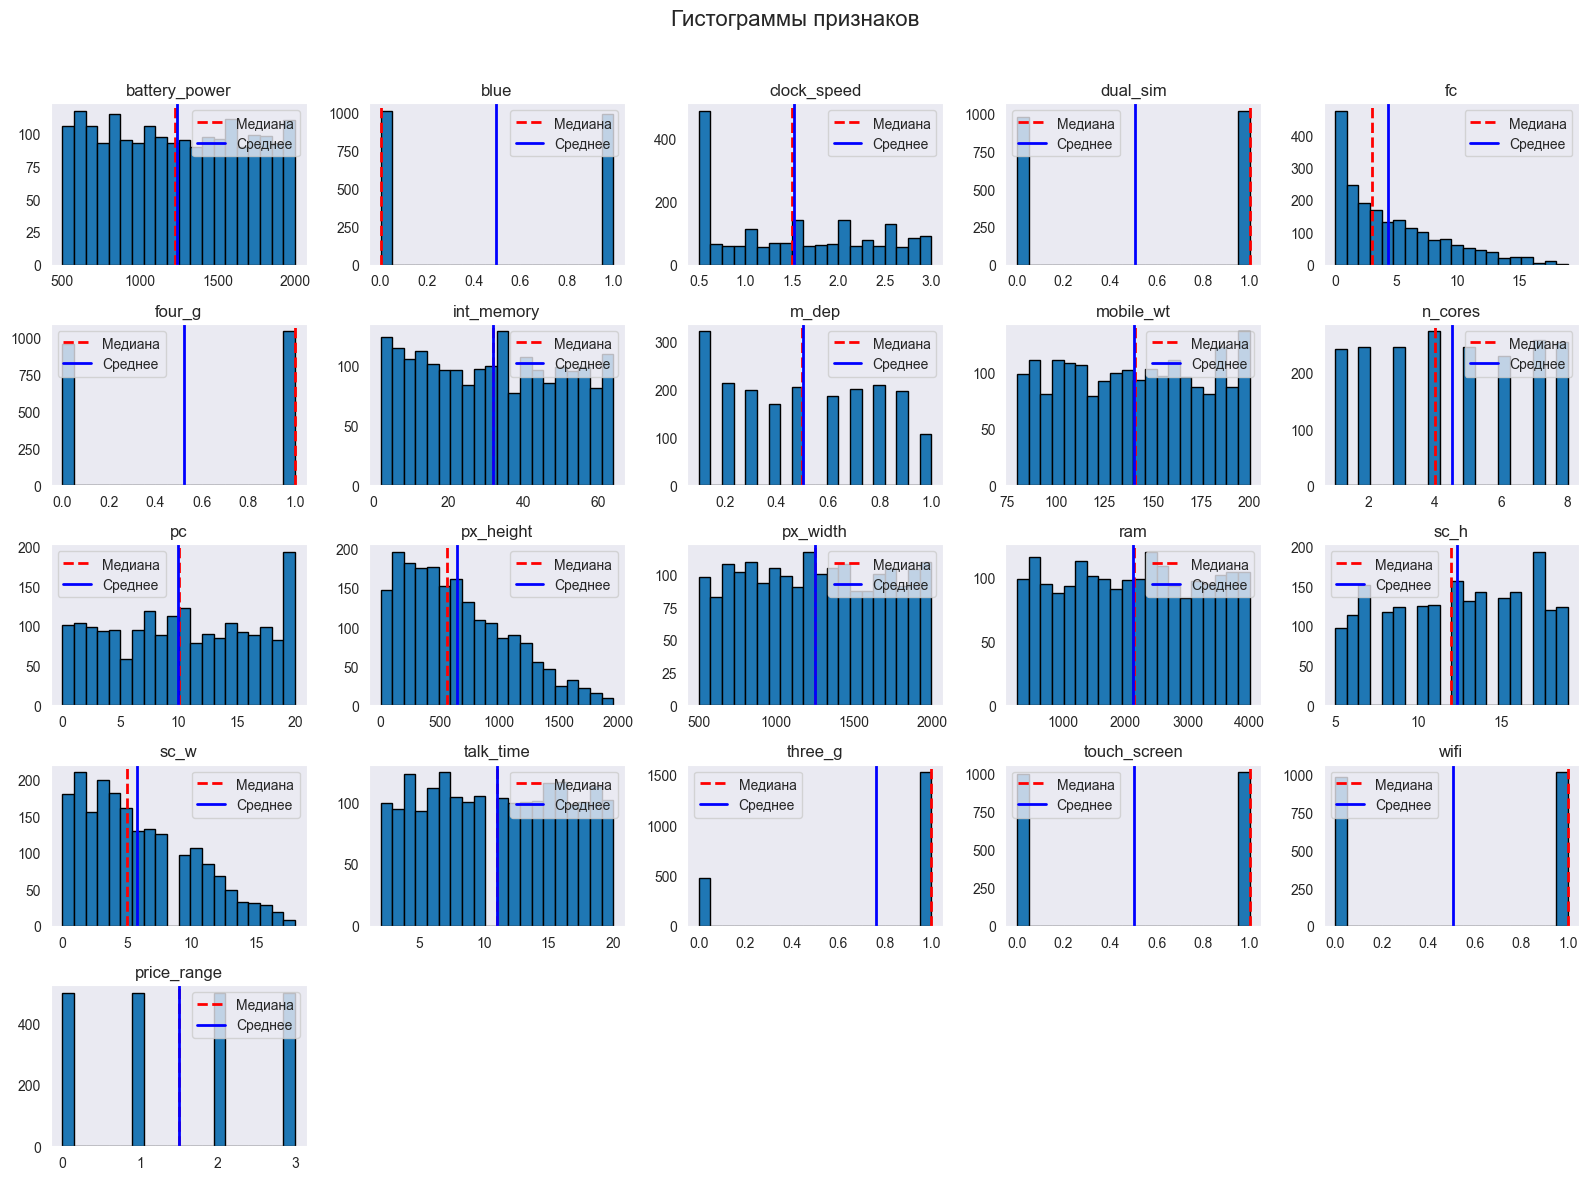

In [41]:
# Рисуем гистограммы
axes = df.hist(bins=20, figsize=(16, 12), grid=False, edgecolor='black')

plt.suptitle("Гистограммы признаков", fontsize=16)

# Проходимся по каждому признаку и соответствующей оси
for i, column in enumerate(df.columns):
    ax = axes.flatten()[i]
    median = df[column].median()
    mean = df[column].mean()

    ax.axvline(median, color='red', linestyle='dashed', linewidth=2, label='Медиана')
    ax.axvline(mean, color='blue', linestyle='solid', linewidth=2, label='Среднее')
    ax.legend()

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Чтобы не перекрывался заголовок
plt.show()

### Кольцевые диаграммы

In [42]:
def create_plot_cat(feature):
    palette = sns.color_palette("Set2")
    value_counts = df[feature].value_counts()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5),
                                   gridspec_kw={'width_ratios': [1, 1]})

    ax1.pie(value_counts, autopct='%0.001f%%', startangle=90, pctdistance=0.85,
            colors=palette, labels=None)
    centre_circle = plt.Circle((0, 0), 0.70, fc='white')
    ax1.add_artist(centre_circle)
    ax1.set_title(f'Кольцевая диаграмма для {feature}', fontsize=16)

    sns.barplot(x=value_counts.index, y=value_counts.values, ax=ax2,
                palette=palette)
    ax2.set_title(f'Барчарты для {feature}', fontsize=16)
    ax2.set_xlabel(f"{feature}", fontsize=14)
    ax2.set_ylabel('Количество', fontsize=14)

    ax2.tick_params(axis='x')

    plt.tight_layout()
    plt.show()

#### Ширина устройства (m_dep)

In [43]:
df['m_dep'].unique()

array([0.6, 0.7, 0.9, 0.8, 0.1, 0.5, 1. , 0.3, 0.4, 0.2])

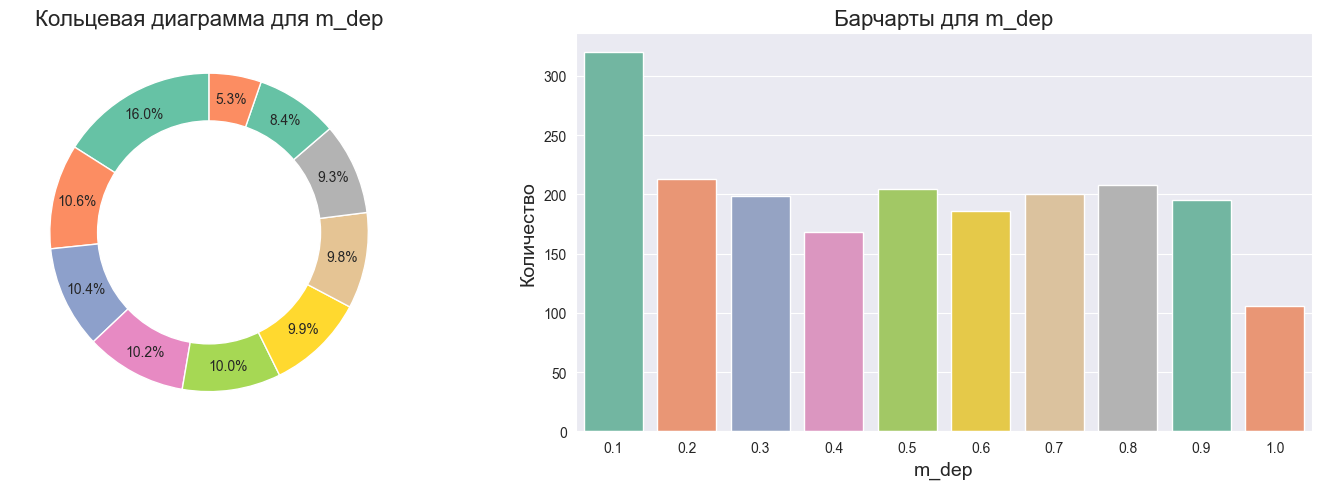

In [44]:
create_plot_cat("m_dep")

#### Количество ядер процессора (n-cores)


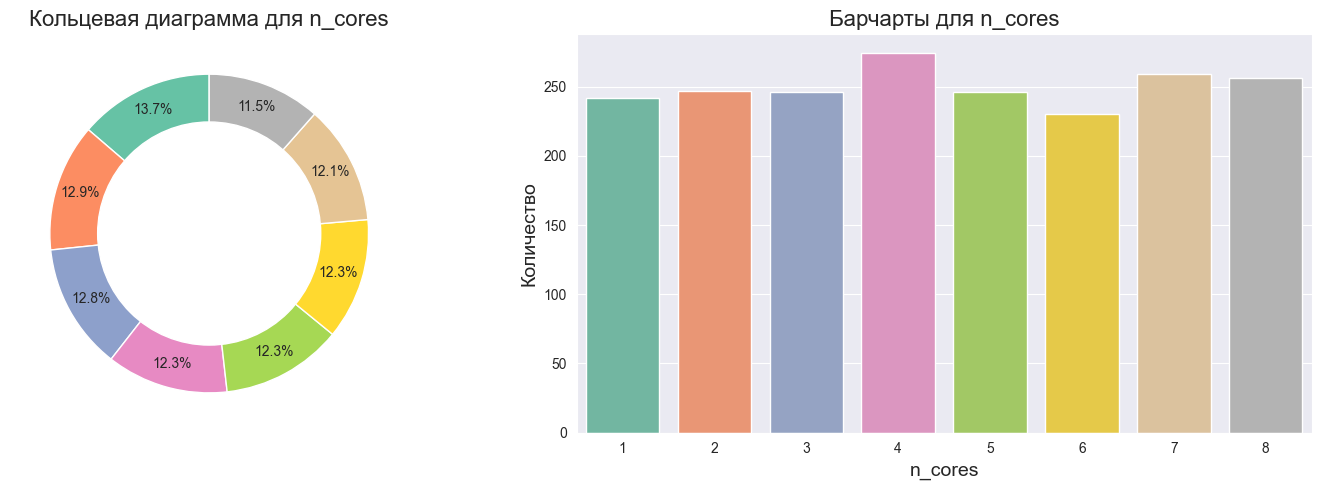

In [45]:
create_plot_cat("n_cores")

#### Высота экрана (см)

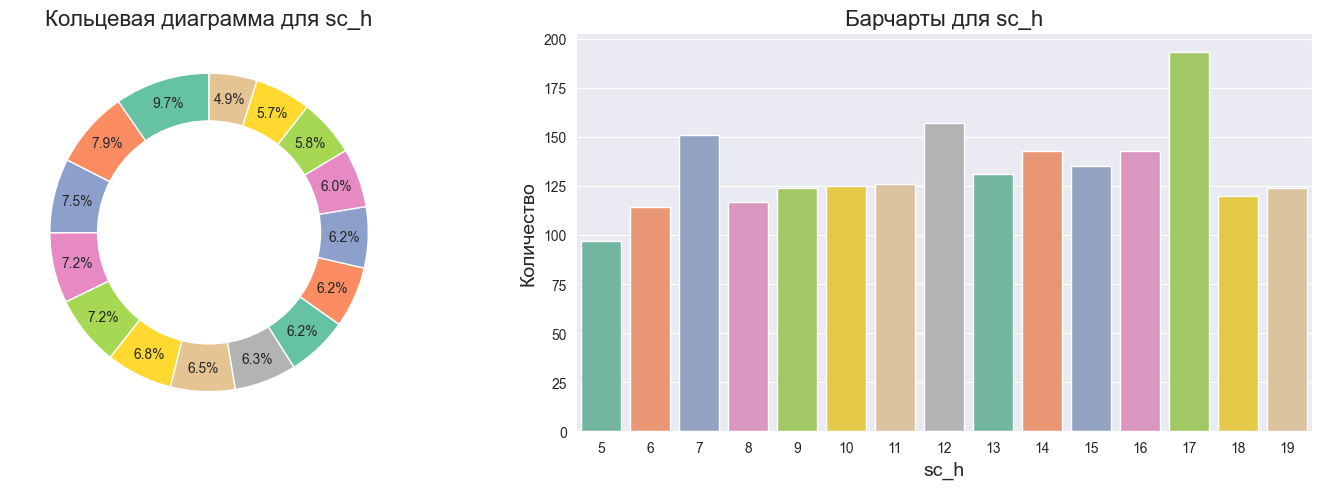

In [46]:
create_plot_cat("sc_h")

#### Цена (price-range)

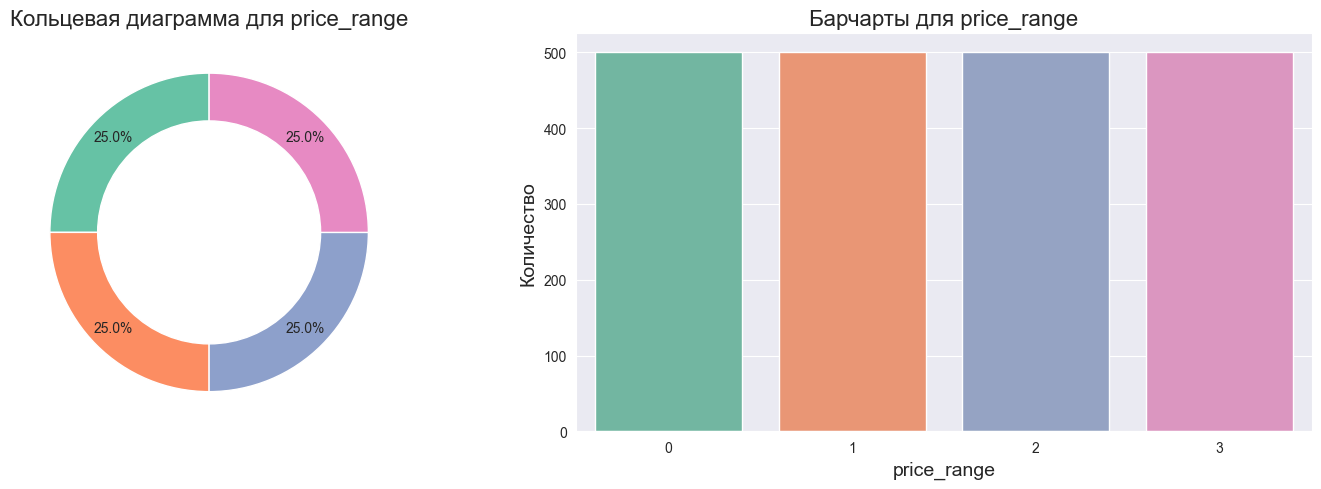

In [47]:
create_plot_cat("price_range")

### Корреляционная матрица

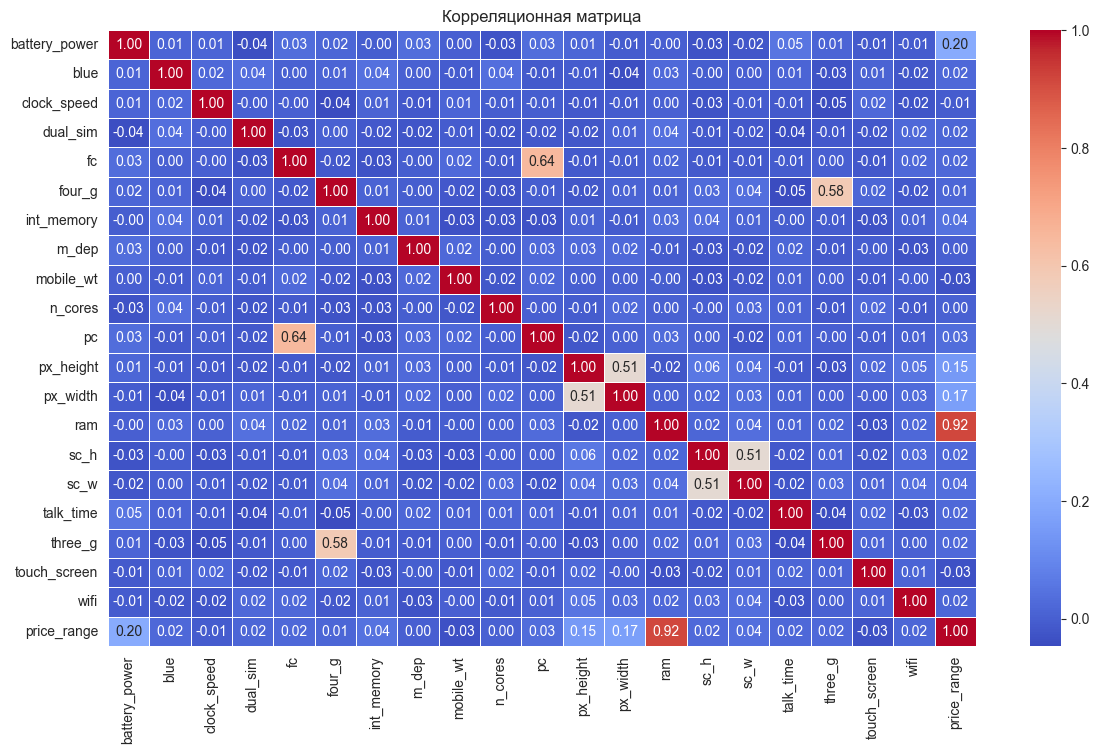

In [48]:
corr_matrix = df.corr()

# Построение графика
plt.figure(figsize=(14, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Корреляционная матрица')
plt.show()

## Разделение на тестовую и обучающую

In [49]:
X = df.drop('price_range', axis=1)
y = df['price_range']

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [51]:
print(type(X_train))
print(type(X_test))
print(type(y_train))
print(type(y_test))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>


## Реализация своего DecisionTree

In [52]:
class MyDecisionTree():
    def __init__(self, max_depth=None, min_samples_split=2):
        """
        max_depth : Максимальная глубина дерева
        min_samples_split : Минимальное количество объектов для разделения узл
        """
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split

    def get_params(self, deep=True): # Для GridSearchCV
        return {
            'max_depth': self.max_depth,
            'min_samples_split': self.min_samples_split
        }

    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self

    def fit(self, X_train, y_train):
        """Обучение модели"""
        # Преобразуем в numpy массивы
        if isinstance(X_train, pd.DataFrame):
            X_train = X_train.values
        if isinstance(y_train, pd.Series):
            y_train = y_train.values

        if len(X_train) == 0:
            raise ValueError("X_train не может быть пустым")
        if len(y_train) == 0:
            raise ValueError("y_train не может быть пустым")

        if len(X_train) != len(y_train):
            raise ValueError(f"Количество объектов в X ({len(X_train)}) и y ({len(y_train)}) не совпадает!")

        self.X_train = X_train.copy()
        self.y_train = y_train.copy()

        self.classes_ = np.unique(y_train)
        self.n_classes_ = len(self.classes_)

        self.n_features_ = X_train.shape[1]

        self.tree_ = self._build_tree(self.X_train, self.y_train, depth=0)

        return self

    def _build_tree(self, X, y, depth):
        """
        Помтроение дерева
        depth: текущая глубина
        """

        # Условие остановки 1: все объекты одного класса
        if len(np.unique(y)) == 1:
            return y[0]

        # Условие остановки 2: достигли максимальной глубины
        if self.max_depth is not None and depth >= self.max_depth:
            unique, counts = np.unique(y, return_counts=True) # Самый частый класс
            return unique[np.argmax(counts)]

        # Условие остановки 3: слишком мало объектов для разделения
        if len(y) < self.min_samples_split:
            unique, counts = np.unique(y, return_counts=True)
            return unique[np.argmax(counts)]

        # Ищем лучшее разбиение
        best_feature, best_threshold = self._best_split(X, y)

        if best_feature is None:
            unique, counts = np.unique(y, return_counts=True)
            return unique[np.argmax(counts)]


        # Разделяем данные
        left_mask = X[:, best_feature] <= best_threshold
        right_mask = ~left_mask
        X_left, y_left = X[left_mask], y[left_mask]
        X_right, y_right = X[right_mask], y[right_mask]

        left_subtree = self._build_tree(X_left, y_left, depth + 1) # Увелиичивам глубину
        right_subtree = self._build_tree(X_right, y_right, depth + 1)

        return (best_feature, best_threshold, left_subtree, right_subtree)

    def _best_split(self, X, y):
        n_samples, n_features = X.shape
        best_gain = -1
        best_feature = None
        best_threshold = None

        for feature in range(n_features):
            feature_values = X[:, feature]
            unique_values = np.unique(feature_values)

            for i in range(len(unique_values) - 1):
                threshold = (unique_values[i] + unique_values[i + 1]) / 2 # (середины между соседними значениями)

                left_mask = feature_values <= threshold # Разделяем по порогу
                right_mask = ~left_mask

                if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                    continue

                y_left = y[left_mask]
                y_right = y[right_mask]

                # Считаем информационный выигрыш
                gain = self._information_gain(y, y_left, y_right)

                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold

    def _gini(self, y):
        """
        Вычисляет критерий Джини
        G = 1 - sum(p_i^2)
        """
        if len(y) == 0:
            return 0

        classes = np.unique(y)
        gini = 1.0

        for c in classes:
            p = np.sum(y == c) / len(y)
            gini -= p ** 2

        return gini

    def _information_gain(self, y, y_left, y_right):
        # Критерий родительского узла
        parent_gini = self._gini(y)

        # Веса для дочерних узлов
        w_left = len(y_left) / len(y)
        w_right = len(y_right) / len(y)

        # Средневзвешенный критерий дочерних узлов
        children_gini = w_left * self._gini(y_left) + w_right * self._gini(y_right)

        ig = parent_gini - children_gini

        return ig

    def predict(self, X_test):
        """Функция предсказаний"""
        if isinstance(X_test, pd.DataFrame):
            X_test = X_test.values

        predictions = [self._predict_one(x, self.tree_) for x in X_test]

        return np.array(predictions)

    def _predict_one(self, x, node):
        """
        x: один объект (массив признаков)
        node: узел дерева (признак, порог, левое, правое)
        """
        # Если это лист — просто возвращаем класс
        if not isinstance(node, tuple):
            return node

        feature, threshold, left, right = node

        # Идем в левое или правое поддерево
        if x[feature] <= threshold:
            return self._predict_one(x, left)
        else:
            return self._predict_one(x, right)

In [53]:
my_dicision_tree = MyDecisionTree()
my_dicision_tree.fit(X_train, y_train)

y_pred = my_dicision_tree.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Точность: {accuracy:.4f}")

Точность: 0.8425


## GridSearchCV для собственной реализации

In [54]:
my_tree = MyDecisionTree()

param_grid = {
    'max_depth': [2, 5, 10, 20, None],
    'min_samples_split': [2, 5, 10, 20, 50]
}

# GridSearchCV
grid_search = GridSearchCV(
    my_tree,
    param_grid,
    scoring='accuracy',
    verbose=1
)

grid_search.fit(X_train, y_train)

# Результаты
print("Лучшие параметры:", grid_search.best_params_)
print("Лучшая точность:", grid_search.best_score_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Лучшие параметры: {'max_depth': 10, 'min_samples_split': 2}
Лучшая точность: 0.82875


Лучшие параметры: {'max_depth': 10, 'min_samples_split': 2}

Лучшая точность: 0.82875

## Лучшая модель

In [55]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Точность:", accuracy)

Точность: 0.845


### Матрица ошибок (Confusion Matrix)

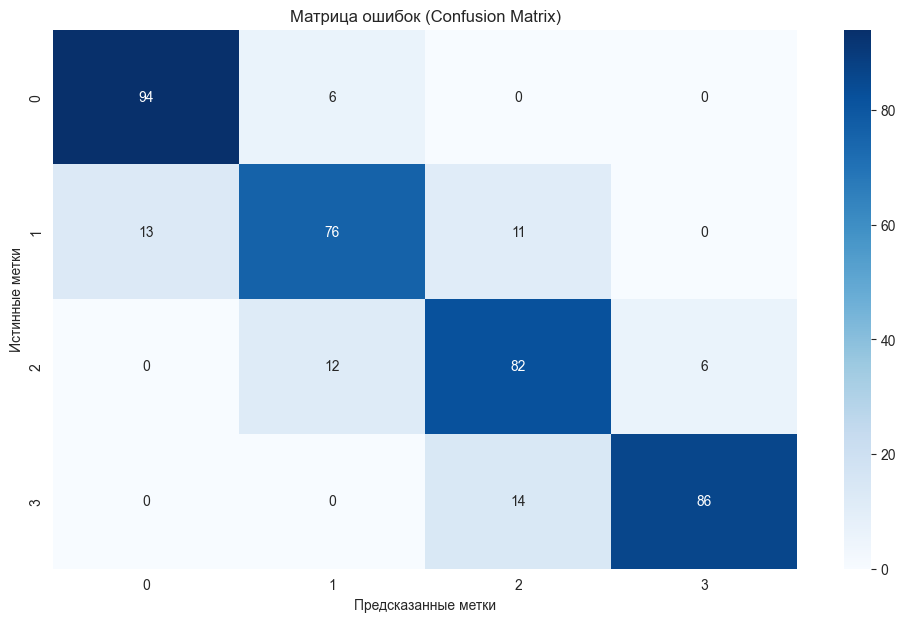

In [56]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['0', '1', '2', '3'], yticklabels=['0', '1', '2', '3'])
plt.title('Матрица ошибок (Confusion Matrix)')
plt.xlabel('Предсказанные метки')
plt.ylabel('Истинные метки')
plt.show()

### Отчёт по классификации

In [57]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.94      0.91       100
           1       0.81      0.76      0.78       100
           2       0.77      0.82      0.79       100
           3       0.93      0.86      0.90       100

    accuracy                           0.84       400
   macro avg       0.85      0.84      0.84       400
weighted avg       0.85      0.84      0.84       400



## Библиотечная реализация

In [58]:
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Точность модели: {accuracy:.4f}")

Точность модели: 0.8300
